# Statistics Comparison
This notebook reads the statistics of two files and plots them side by side for comparison.

In [190]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [207]:
statistics = 'median'
mixed = False

#filename1 = 'sgqt_for_mixed'
filename1 = 'sgqt_without_truncation'

filename2 = filename1 + '_stop'

In [208]:
# Load the first file
filepath1 = os.path.join('data', filename1 + '.npz')
with np.load(filepath1) as data1:
    NQs1 = data1['NQs']
    Fids1 = data1['Fids']
    Meas1 = data1['Meas']

if mixed:
    Fids1 = Fids1[:, :, :, mixed-1]

In [209]:
# Load the second file
filepath2 = os.path.join('data', filename2 + '.npz')
with np.load(filepath2) as data2:
    NQs2 = data2['NQs']
    Fids2 = data2['Fids']
    Meas2 = data2['Meas']

if mixed:
    Fids2 = Fids2[:, :, :, mixed-1]

In [210]:
# Function to compute statistics
def compute_statistics(A, axis=1, statistics='median'):
    match statistics:
        case 'median':
            center = np.median(A, axis=axis)
            dev = (np.quantile(A, 0.25, axis=axis), np.quantile(A, 0.75, axis=axis))
        case 'mean':
            center = np.mean(A, axis=axis)
            std = np.std(A, axis=axis)
            dev = (center - std, center + std)

    return center, dev

In [211]:
# Compute statistics for both files
center1, dev1 = compute_statistics(Fids1, axis=1, statistics=statistics)
center2, dev2 = compute_statistics(Fids2, axis=1, statistics=statistics)

# Compute statistics for the measurements
meas_center1, meas_dev1 = compute_statistics(Meas1, axis=1, statistics=statistics)
meas_center2, meas_dev2 = compute_statistics(Meas2, axis=1, statistics=statistics)


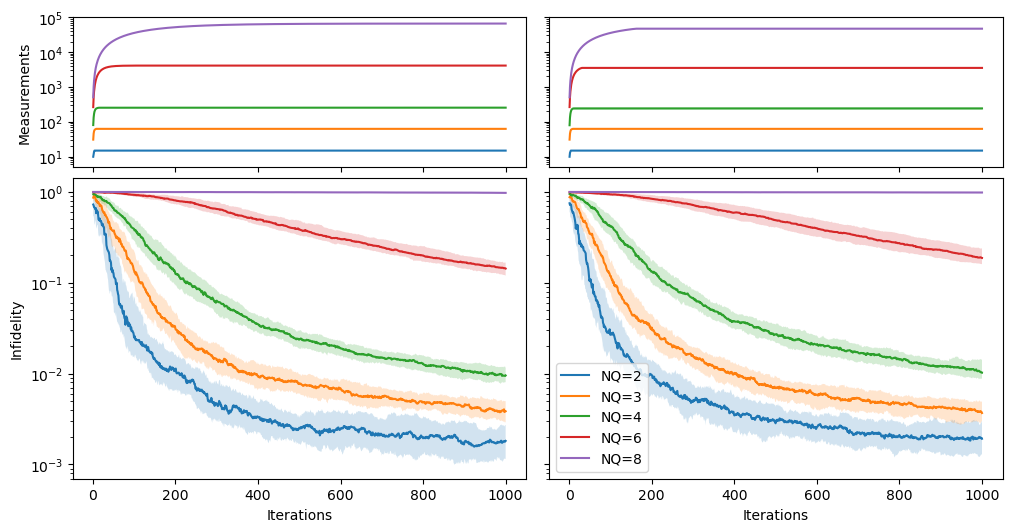

In [212]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey='row',
                       gridspec_kw={'height_ratios': [1, 2]})    

fig.subplots_adjust(wspace=0.05, hspace=0.05)

for i, nq in enumerate(NQs1):
    iters = np.arange(meas_center1.shape[1]) + 1
    ax[0, 0].semilogy(iters, meas_center1[i], label=f'NQ={nq}')
    ax[0, 0].fill_between(iters, meas_dev1[0][i], meas_dev1[1][i], alpha=0.2)

for i, nq in enumerate(NQs2):
    iters = np.arange(meas_center2.shape[1]) + 1
    ax[0, 1].semilogy(iters, meas_center2[i], label=f'NQ={nq}')
    ax[0, 1].fill_between(iters, meas_dev2[0][i], meas_dev2[1][i], alpha=0.2)


for i, nq in enumerate(NQs1):
    iters = np.arange(center1.shape[1]) + 1
    ax[1, 0].semilogy(iters, center1[i], label=f'NQ={nq}')
    ax[1, 0].fill_between(iters, dev1[0][i], dev1[1][i], alpha=0.2)

for i, nq in enumerate(NQs2):
    iters = np.arange(center2.shape[1]) + 1
    ax[1, 1].semilogy(iters, center2[i], label=f'NQ={nq}')
    ax[1, 1].fill_between(iters, dev2[0][i], dev2[1][i], alpha=0.2)


ax[0,0].set_ylabel('Measurements')
ax[1,0].set_ylabel('Infidelity')

ax[1,0].set_xlabel('Iterations')
ax[1,1].set_xlabel('Iterations')

plt.legend()
plt.savefig(filename1 + '.png')